# 🏃 Chương 4 — Dataset 4: HAR Sensor Data — GRU Time Series
## Kỹ thuật: Human Activity Recognition + Bidirectional GRU + Sensor Visualization

**Pipeline:** EDA → Sensor Signal Analysis → Sliding Window → BiGRU → Train → Per-Class Evaluation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import glob, os, warnings

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

DATA_DIR    = '../data/har'
SAVE_DIR    = '../results/har_gru'
os.makedirs(SAVE_DIR, exist_ok=True)

EPOCHS      = 25
BATCH_SIZE  = 64

print(f'TF: {tf.__version__}')

2026-05-09 20:19:42.128160: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 20:19:42.159204: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 20:19:42.713816: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TF: 2.13.0


## 📂 1. Load HAR Dataset

In [2]:
# HAR datasets usually come in train/test subdirs or as single CSV
# Try UCI HAR format first (txt files with separate X/y)

def try_load_uci_format(base_dir):
    for split in ['train','test','Train','Test']:
        xdir = os.path.join(base_dir, split)
        if not os.path.exists(xdir):
            continue
        x_files = glob.glob(os.path.join(xdir, 'X_*.txt'))
        y_files = glob.glob(os.path.join(xdir, 'y_*.txt'))
        if x_files and y_files:
            X = pd.read_csv(x_files[0], delim_whitespace=True, header=None).values
            y = pd.read_csv(y_files[0], header=None).values.flatten() - 1
            print(f'Loaded UCI format from {split}: X={X.shape}, y={y.shape}')
            return X, y, split
    return None, None, None

X_train_raw, y_train_raw, _ = try_load_uci_format(DATA_DIR)

if X_train_raw is None:
    # Try CSV format
    csv_files = glob.glob(f'{DATA_DIR}/**/*.csv', recursive=True) + glob.glob(f'{DATA_DIR}/*.csv')
    print('Found CSV:', csv_files)
    df = pd.read_csv(csv_files[0])
    
    label_col = [c for c in df.columns if any(k in c.lower() for k in ['activity','label','class'])]
    label_col = label_col[0] if label_col else df.columns[-1]
    feature_cols = [c for c in df.columns if c != label_col and df[c].dtype != object]
    
    le = LabelEncoder()
    labels = le.fit_transform(df[label_col])
    features = df[feature_cols].values
    
    from sklearn.model_selection import train_test_split
    X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
        features, labels, test_size=0.2, random_state=42, stratify=labels)
    
    CLASSES = le.classes_.tolist()
    print(f'Classes ({len(CLASSES)}): {CLASSES}')
else:
    CLASSES = ['WALKING','WALKING_UPSTAIRS','WALKING_DOWNSTAIRS','SITTING','STANDING','LAYING']
    # Load test
    X_test_raw, y_test_raw, _ = try_load_uci_format(DATA_DIR.replace('train','test'))
    if X_test_raw is None:
        # Try from same dir
        xtest_f = glob.glob(f'{DATA_DIR}/**/X_test.txt', recursive=True)
        ytest_f = glob.glob(f'{DATA_DIR}/**/y_test.txt', recursive=True)
        if xtest_f:
            X_test_raw = pd.read_csv(xtest_f[0], delim_whitespace=True, header=None).values
            y_test_raw = pd.read_csv(ytest_f[0], header=None).values.flatten() - 1

NUM_CLASSES = len(np.unique(y_train_raw))
print(f'Train: {X_train_raw.shape}, Test: {X_test_raw.shape}')
print(f'Num classes: {NUM_CLASSES}')

Found CSV: ['../data/har/test.csv', '../data/har/train.csv', '../data/har/test.csv', '../data/har/train.csv']
Classes (6): ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
Train: (2357, 562), Test: (590, 562)
Num classes: 6


## 📊 2. EDA — Sensor Signal Analysis

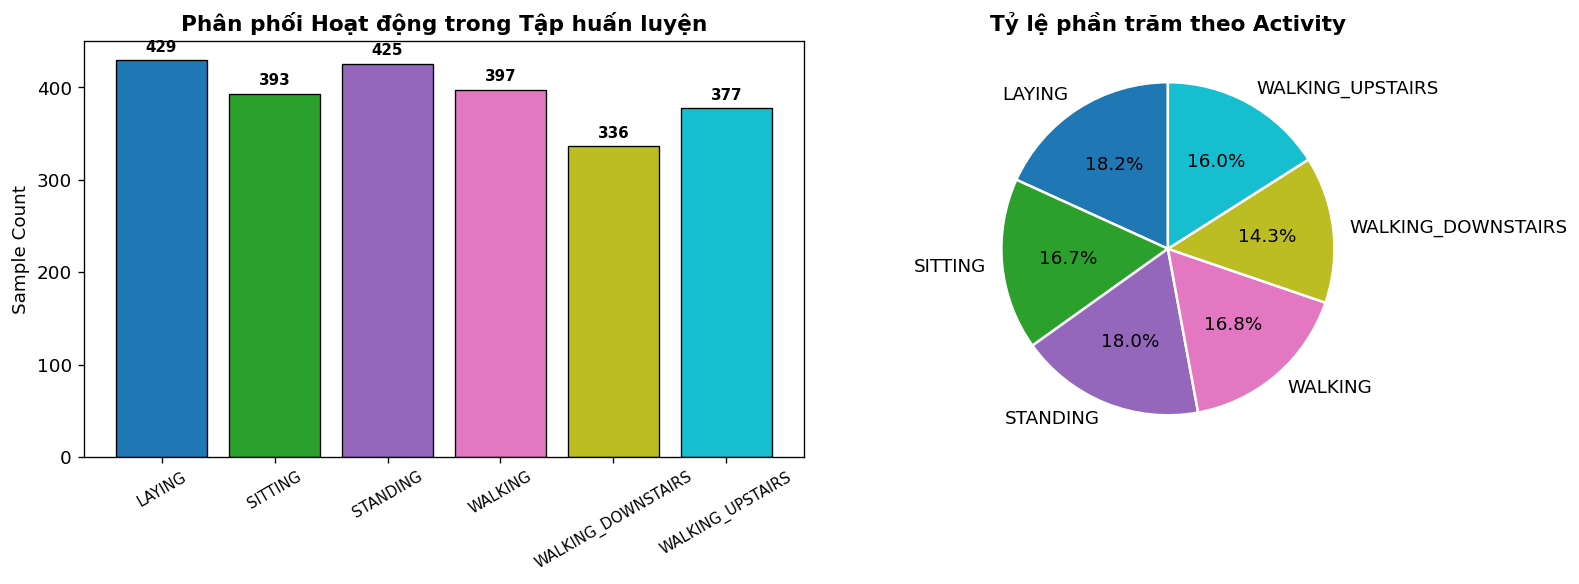

In [3]:
# Class distribution
unique_labels, counts = np.unique(y_train_raw, return_counts=True)
class_labels = [CLASSES[i] if i < len(CLASSES) else f'Class {i}' for i in unique_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
bars = axes[0].bar(class_labels, counts, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Phân phối Hoạt động trong Tập huấn luyện')
axes[0].set_ylabel('Sample Count')
axes[0].tick_params(axis='x', rotation=30, labelsize=9)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

axes[1].pie(counts, labels=class_labels, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Tỷ lệ phần trăm theo Activity')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_class_distribution.png', bbox_inches='tight')
plt.show()

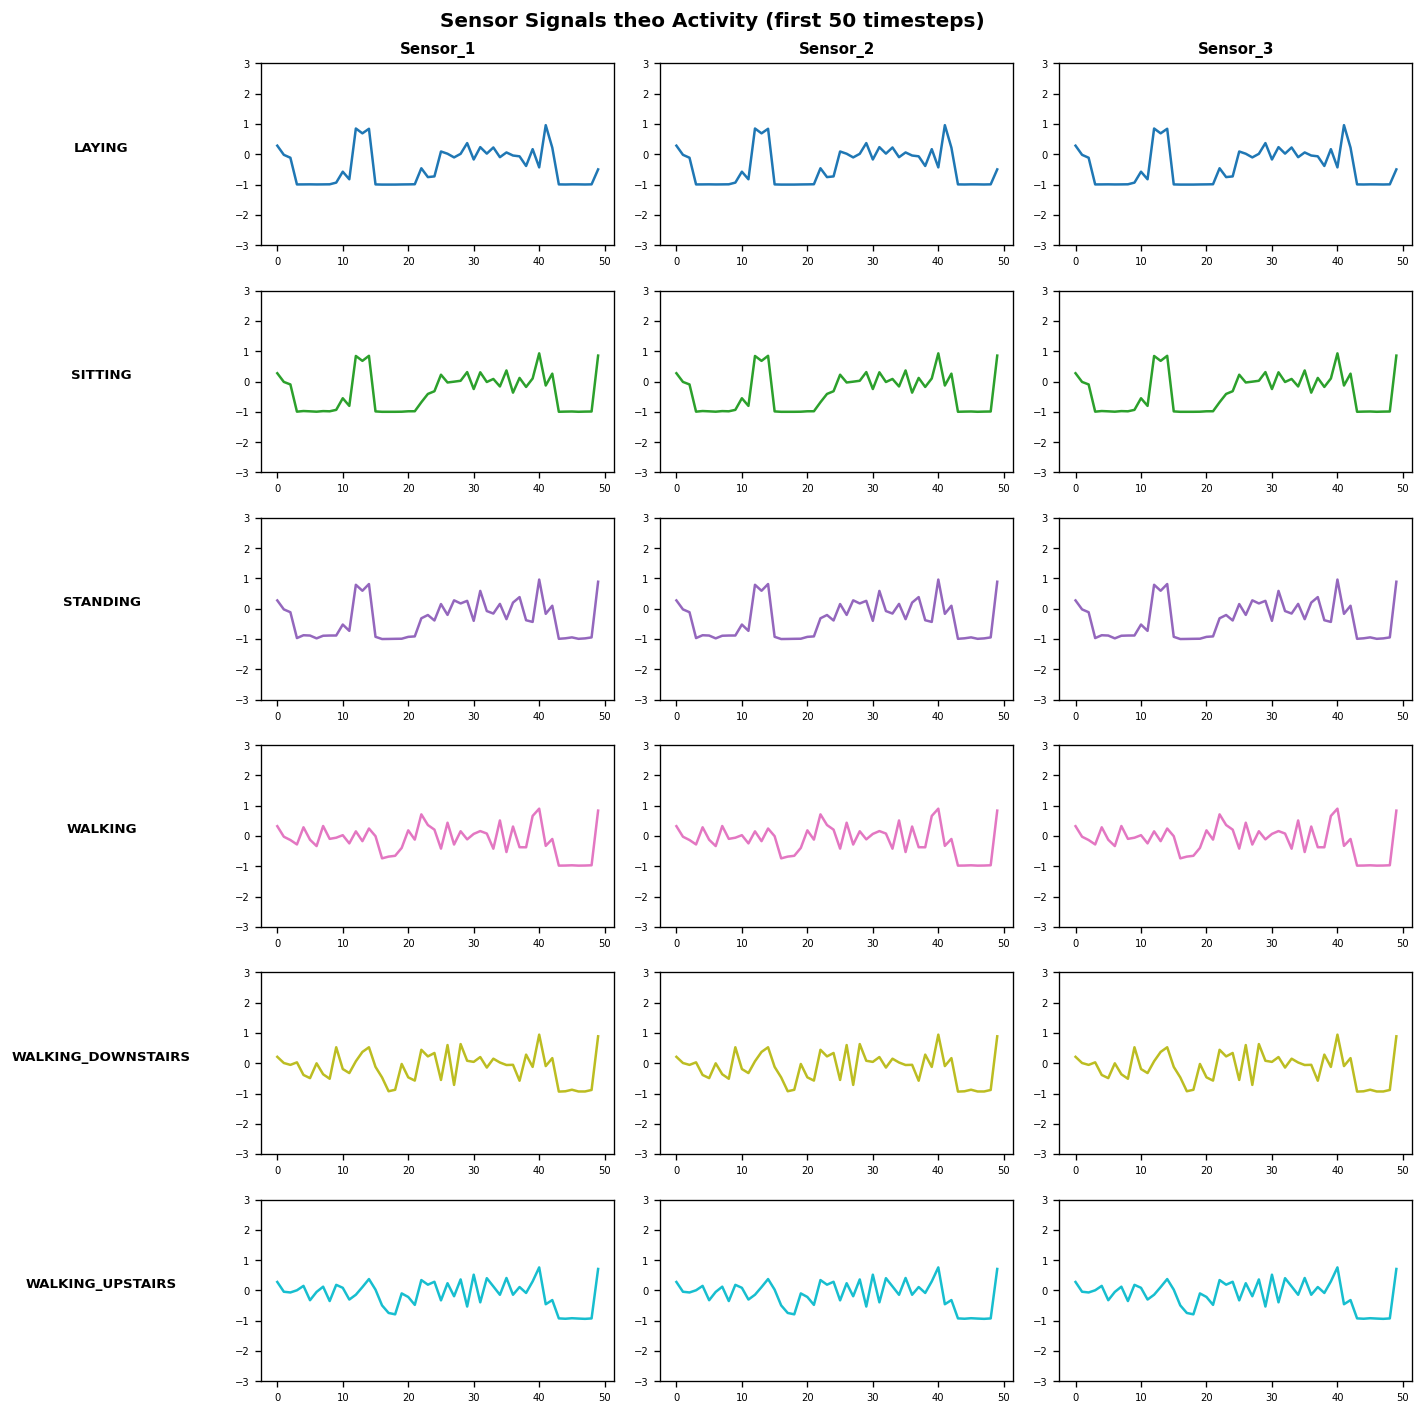

In [4]:
# Sensor signal comparison per activity
# Use first 3 features as proxy for accelerometer axes
n_features_display = min(3, X_train_raw.shape[1])
feature_names = [f'Sensor_{i+1}' for i in range(n_features_display)]

fig, axes = plt.subplots(NUM_CLASSES, n_features_display,
                          figsize=(4*n_features_display, 2*NUM_CLASSES))

for r, lbl in enumerate(unique_labels):
    idx = np.where(y_train_raw == lbl)[0][:1][0]
    label_name = CLASSES[lbl] if lbl < len(CLASSES) else f'Class {lbl}'
    for c in range(n_features_display):
        signal = X_train_raw[idx, :]
        axes[r, c].plot(signal[:min(50, len(signal))],
                         color=colors[r], lw=1.5)
        axes[r, c].set_ylim(-3, 3)
        if c == 0:
            axes[r, c].set_ylabel(label_name, rotation=0, labelpad=80,
                                   fontsize=8, fontweight='bold')
        if r == 0:
            axes[r, c].set_title(feature_names[c], fontsize=9)
        axes[r, c].tick_params(labelsize=6)

plt.suptitle('Sensor Signals theo Activity (first 50 timesteps)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_sensor_signals.png', bbox_inches='tight')
plt.show()

## ⚙️ 3. Preprocessing

In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_raw)
X_test_s  = scaler.transform(X_test_raw)

# Reshape for LSTM: (samples, timesteps, features)
# If flat features, treat each feature as a timestep
X_train_3d = X_train_s.reshape(X_train_s.shape[0], X_train_s.shape[1], 1)
X_test_3d  = X_test_s.reshape(X_test_s.shape[0],  X_test_s.shape[1],  1)

print(f'Input shape: {X_train_3d.shape} → (samples, features, 1)')
print(f'Labels: {y_train_raw.shape}')

Input shape: (2357, 562, 1) → (samples, features, 1)
Labels: (2357,)


## 🏗️ 4. Bidirectional GRU Model

In [6]:
input_shape = X_train_3d.shape[1:]

model = models.Sequential([
    layers.Bidirectional(
        layers.GRU(128, return_sequences=True),
        input_shape=input_shape,
        name='bigru_1'
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Bidirectional(
        layers.GRU(64, return_sequences=False),
        name='bigru_2'
    ),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax', name='output')
], name='BiGRU_HAR')

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

2026-05-09 20:19:45.359241: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 20:19:45.361688: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 20:19:45.363725: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "BiGRU_HAR"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bigru_1 (Bidirectional)     (None, 562, 256)          100608    
                                                                 
 batch_normalization (Batch  (None, 562, 256)          1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 562, 256)          0         
                                                                 
 bigru_2 (Bidirectional)     (None, 128)               123648    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                         

## 🚀 5. Training

In [7]:
history = model.fit(
    X_train_3d, y_train_raw,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)

Epoch 1/25
34/34 [==============================] - 17s 407ms/step - loss: 1.1372 - accuracy: 0.5007 - val_loss: 1.3506 - val_accuracy: 0.5551 - lr: 0.0010
Epoch 2/25
34/34 [==============================] - 13s 372ms/step - loss: 0.7106 - accuracy: 0.6950 - val_loss: 1.1600 - val_accuracy: 0.5381 - lr: 0.0010
Epoch 3/25
34/34 [==============================] - 12s 365ms/step - loss: 0.5936 - accuracy: 0.7440 - val_loss: 1.0469 - val_accuracy: 0.5127 - lr: 0.0010
Epoch 4/25
34/34 [==============================] - 12s 365ms/step - loss: 0.5552 - accuracy: 0.7619 - val_loss: 0.9396 - val_accuracy: 0.5890 - lr: 0.0010
Epoch 5/25
34/34 [==============================] - 12s 366ms/step - loss: 0.5240 - accuracy: 0.7727 - val_loss: 0.8657 - val_accuracy: 0.5805 - lr: 0.0010
Epoch 6/25
34/34 [==============================] - 13s 374ms/step - loss: 0.5091 - accuracy: 0.7775 - val_loss: 0.7907 - val_accuracy: 0.6653 - lr: 0.0010
Epoch 7/25
34/34 [==============================] - 12s 362ms/st

## 📈 6. Evaluation

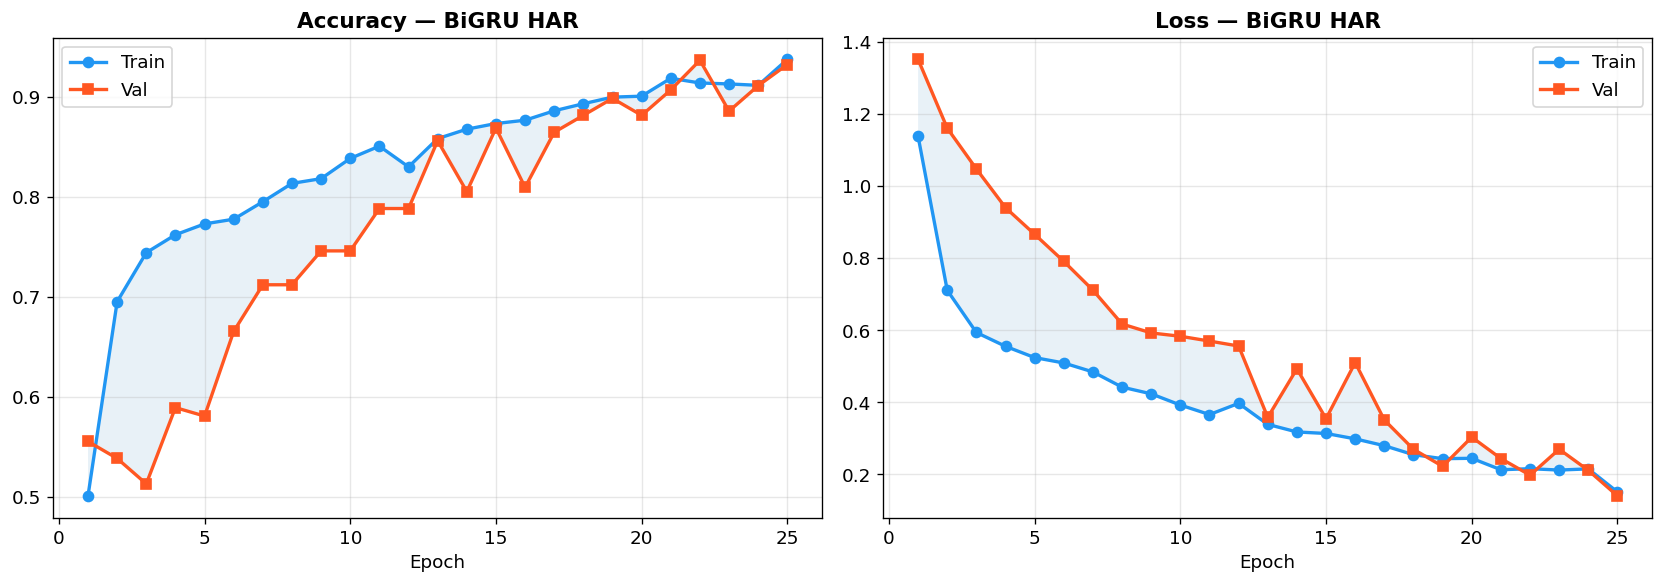

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(history.history['accuracy'])+1)

for ax, (tr, vl, metric) in zip(axes, [
    ('accuracy','val_accuracy','Accuracy'),
    ('loss','val_loss','Loss')
]):
    ax.plot(eps, history.history[tr], 'o-', color='#2196F3', lw=2, label='Train')
    ax.plot(eps, history.history[vl], 's-', color='#FF5722', lw=2, label='Val')
    ax.fill_between(eps, history.history[tr], history.history[vl], alpha=0.1)
    ax.set_title(f'{metric} — BiGRU HAR')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_training_history.png', bbox_inches='tight')
plt.show()

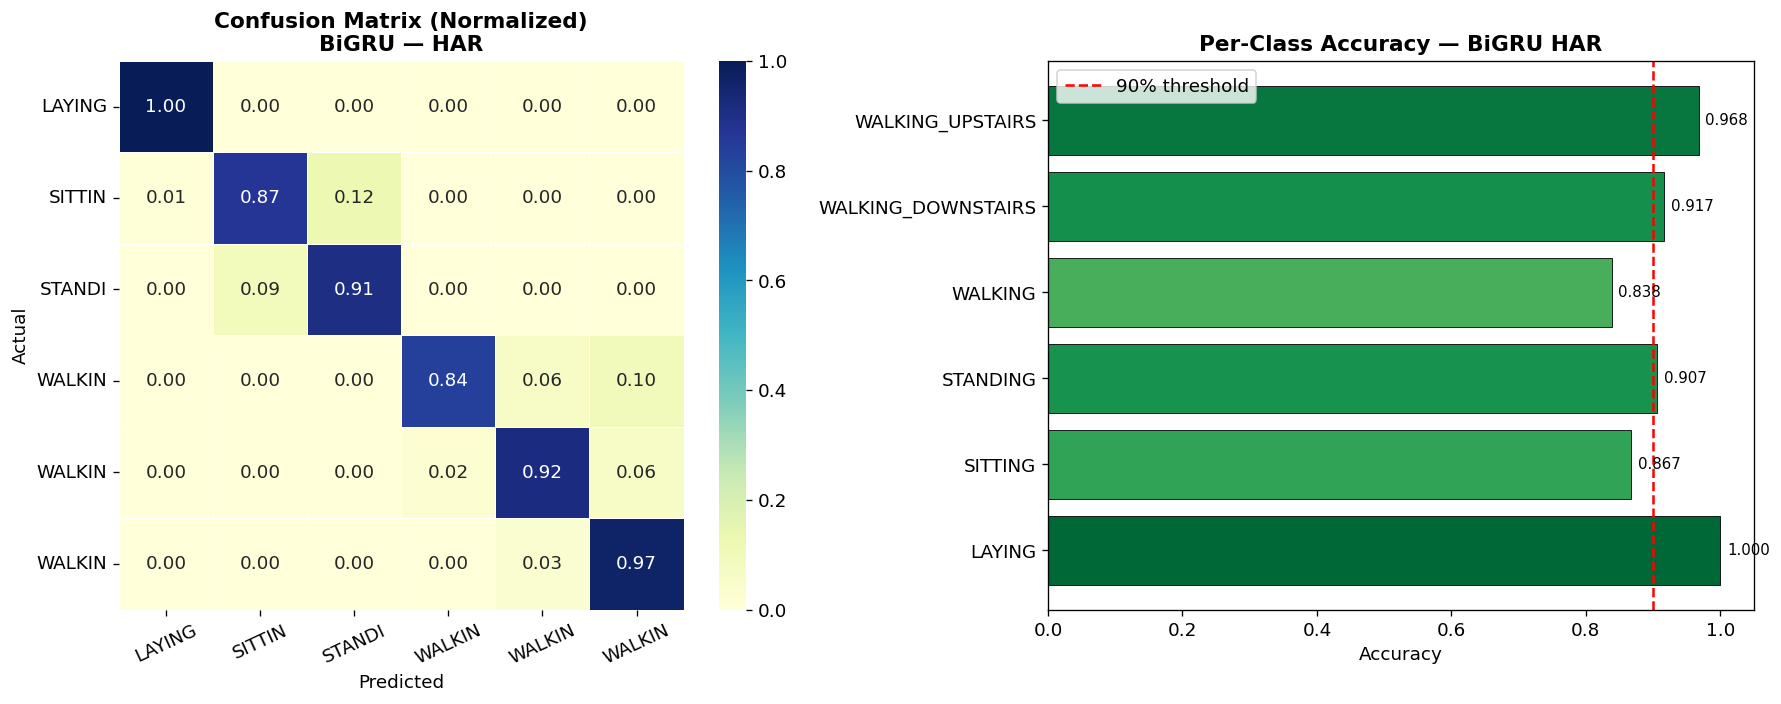

                    precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00       108
           SITTING       0.89      0.87      0.88        98
          STANDING       0.89      0.91      0.90       107
           WALKING       0.98      0.84      0.90        99
WALKING_DOWNSTAIRS       0.90      0.92      0.91        84
  WALKING_UPSTAIRS       0.86      0.97      0.91        94

          accuracy                           0.92       590
         macro avg       0.92      0.92      0.92       590
      weighted avg       0.92      0.92      0.92       590



In [9]:
y_pred_prob = model.predict(X_test_3d, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test_raw

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=[c[:6] for c in class_labels],
            yticklabels=[c[:6] for c in class_labels],
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix (Normalized)\nBiGRU — HAR')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=25)
axes[0].tick_params(axis='y', rotation=0)

# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
bars = axes[1].barh(class_labels, per_class_acc,
                     color=plt.cm.RdYlGn(per_class_acc), edgecolor='black', linewidth=0.5)
axes[1].axvline(0.9, color='red', linestyle='--', lw=1.5, label='90% threshold')
axes[1].set_title('Per-Class Accuracy — BiGRU HAR')
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim(0, 1.05)
for bar, val in zip(bars, per_class_acc):
    axes[1].text(val+0.01, bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_confusion_perclass.png', bbox_inches='tight')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_labels))

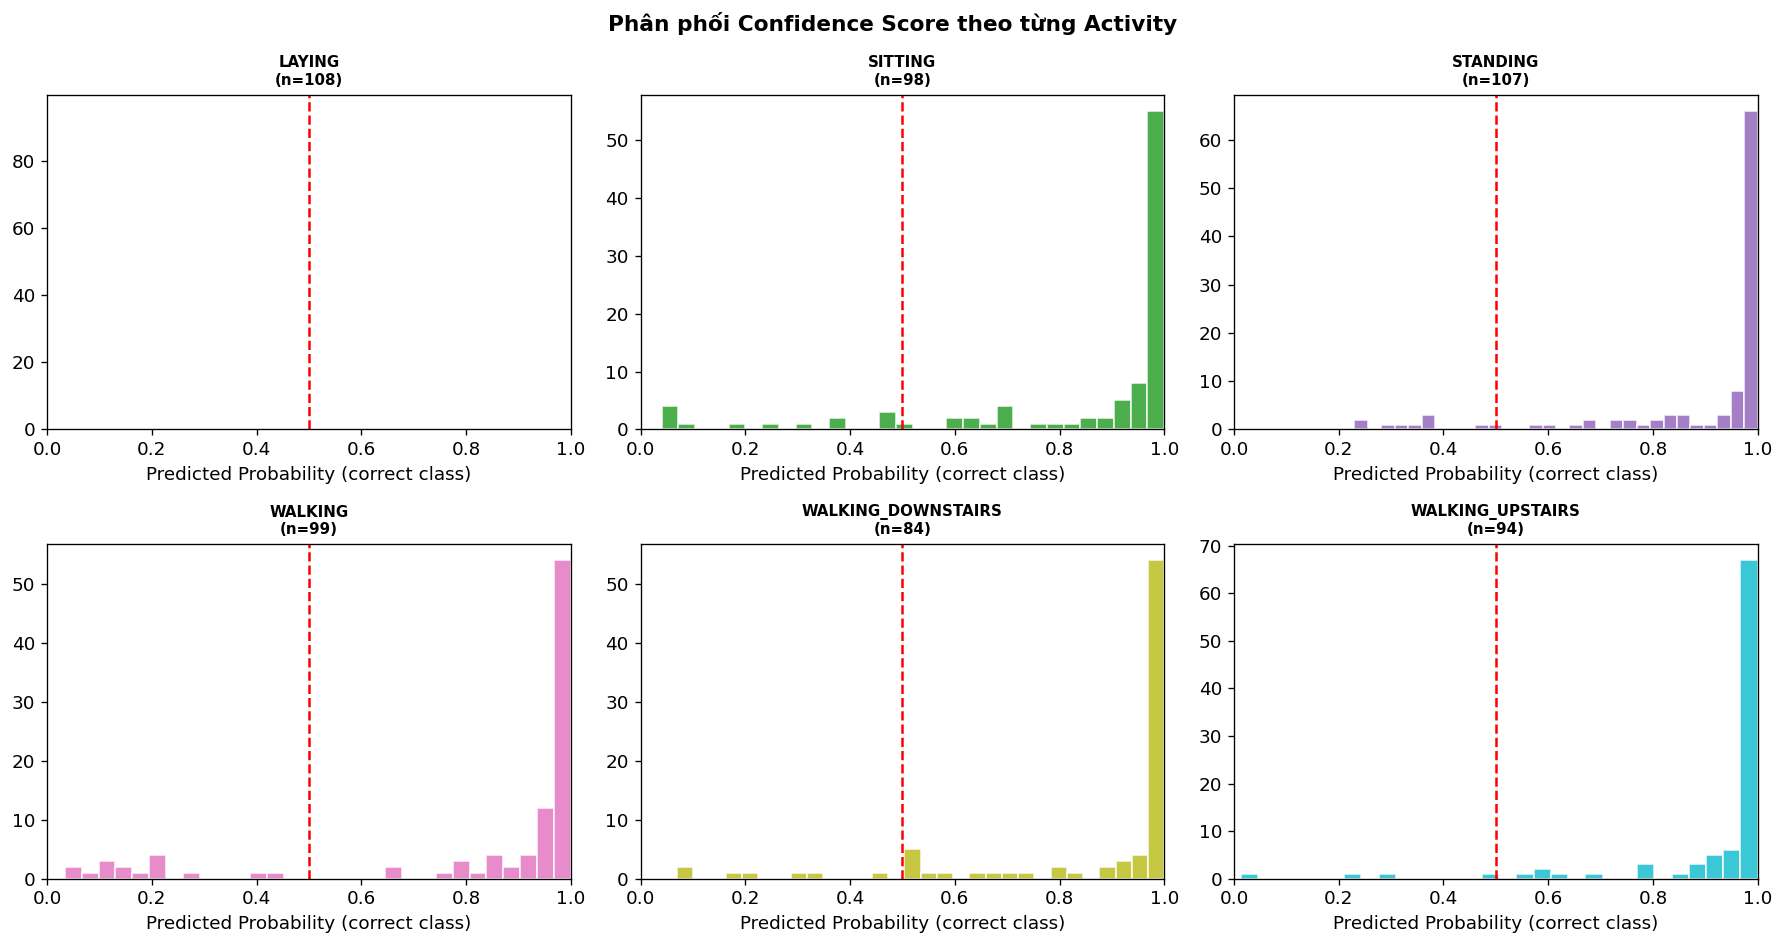

In [10]:
# Per-class probability confidence distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (lbl, name) in enumerate(zip(unique_labels, class_labels)):
    if i >= len(axes): break
    idx = np.where(y_true == lbl)[0]
    probs_correct_class = y_pred_prob[idx, lbl]
    axes[i].hist(probs_correct_class, bins=30, color=colors[i],
                 edgecolor='white', alpha=0.85)
    axes[i].axvline(0.5, color='red', linestyle='--', lw=1.5)
    axes[i].set_title(f'{name}\n(n={len(idx):,})', fontsize=9)
    axes[i].set_xlabel('Predicted Probability (correct class)')
    axes[i].set_xlim(0, 1)

# Hide extra subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phân phối Confidence Score theo từng Activity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_confidence_distribution.png', bbox_inches='tight')
plt.show()

In [11]:
best_acc = max(history.history['val_accuracy'])
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('HAR Sensor Data — Bidirectional GRU\n' + '='*50 + '\n')
    f.write(f'Best Val Accuracy: {best_acc:.4f}\n')
    f.write(f'Total Params: {model.count_params():,}\n\n')
    f.write('Per-Class Accuracy:\n')
    for name, acc in zip(class_labels, per_class_acc):
        f.write(f'  {name:25s}: {acc:.4f}\n')
    f.write('\n' + classification_report(y_true, y_pred, target_names=class_labels))

print('✅ HAR BiGRU Experiment Done! Saved to', SAVE_DIR)

✅ HAR BiGRU Experiment Done! Saved to ../results/har_gru
